# Serving, Simulation Eval, and Closing the Loop

## TLDR

You take the PI0.5 checkpoint fine-tuned in notebook 02, deploy it as an HTTP
service with **Ray Serve** on one GPU, then fan out **Isaac Lab** Franka rollouts
as **`@ray.remote(num_gpus=1)`** tasks — each its own GPU, process, and
simulator — that query the policy over HTTP. Then you **close the loop**: filter
the sim trajectories by reward, `union()` the good ones into the LIBERO stream,
and retrain. The reward comparison between rounds is the payoff.

## Introduction

A policy is only useful if you can run it and evaluate it. Two infrastructure
facts shape this notebook:

1. **The policy and the simulator cannot share a process or a GPU.** PI0.5's
   PyTorch runtime and Isaac Sim's Kit engine contend for memory and have
   conflicting event loops. So the policy runs as a **Ray Serve** deployment on
   its own GPU, and each simulator runs in a **separate subprocess on its own
   GPU**, talking to the policy over HTTP — exactly how a real robot would call
   a remote inference service.

2. **Closing the loop is a data operation.** Once sim rollouts exist as
   trajectory files with rewards, folding the good ones back into training is
   one Ray Data `union()`. The training code from notebook 02 does not change at
   all — only the dataset does.

> **Scope:** PI0.5 was fine-tuned on LIBERO's Panda; we evaluate on Isaac Lab's
> Franka. The embodiments differ, so expect exploratory motion and low,
> noisy rewards. We are validating the **orchestration loop**, not manipulation
> skill. At smoke scale (50 train steps), rewards won't move much — the loss and
> the *architecture* are the lesson.

## Key concepts used in this notebook

**Ray Serve** runs a Python class as a scalable HTTP service. `@serve.deployment`
declares the service (here pinned to 1 GPU); `@serve.ingress(FastAPI())` exposes
routes; `serve.run(...)` deploys it. This is the same primitive used to serve
LLMs in production.

**Pickle-over-HTTP.** Sim workers POST a pickled observation dict and get a
pickled action chunk back. Pickle (not JSON) keeps numpy arrays intact.

**`@ray.remote(num_gpus=1)`** turns a function into a task that Ray schedules on
a free GPU. We launch `SIM_WORKERS` of them; Ray places each on its own GPU and
isolates failures.

**Subprocess, not actor.** Isaac Sim's Kit engine uses asyncio internally; inside
a Ray actor's event loop scene-loading crashes. So each sim task shells out to
`sim_worker.py`, giving Isaac a clean interpreter + event loop.

**`ray.data.union()`** interleaves two datasets during iteration — the entire
data-mixing implementation for the closed loop.

## What you will learn

- Deploy a GPU policy as an HTTP service with **Ray Serve**
- Fan out parallel **Isaac Lab** rollouts as `@ray.remote(num_gpus=1)` tasks
- Understand the subprocess + HTTP boundary between policy and simulator
- Filter sim trajectories by reward and **`union()`** them into the training
  stream — closing the loop with one line
- Retrain on the mixed data with the **unchanged** `TorchTrainer` from 02 and
  compare rewards across rounds

## Why Ray Serve + Ray tasks?

| Need | Without Ray | With Ray |
|---|---|---|
| Policy as a service on its own GPU | Custom server + device management | `@serve.deployment(num_gpus=1)` + `serve.run` |
| N parallel simulators, each on a GPU | Manual process pool + GPU assignment | `@ray.remote(num_gpus=1)`, Ray schedules |
| Policy/sim runtime isolation | Hope they coexist | Separate processes, HTTP boundary |
| Fault isolation | One crash kills the run | Per-task isolation, free |
| Mix sim data into training | Custom sampler/DataLoader | `libero_ds.union(sim_ds)` |

## Architecture

```
         +------------------------+
         |   Ray Serve replica    |  1 x L4 GPU
         |   PI0.5 policy :8000   |<------- POST /predict (pickled obs) --------+
         +------------------------+                                            |
                                                                               |
   +------------------------ @ray.remote(num_gpus=1) -------------------------+|
   |  sim_worker.py (subprocess)        sim_worker.py (subprocess)            ||
   |  Isaac Lab Franka  -- 1xL4 --      Isaac Lab Franka  -- 1xL4 --          ||
   |   reset->obs->[query policy]->step  reset->obs->[query policy]->step ----+|
   |   saves GIF + trajectory.pkl        saves GIF + trajectory.pkl
   +---------------------------------------------------------------------------+
                              | trajectories/*.pkl (reward in filename)
                              v
        filter reward >= theta -> ray.data.from_items -> libero_ds.union(sim_ds)
                              |
                              v  retrain (notebook 02's TorchTrainer, unchanged)
```

## Cell 1: Configuration

**What you do** — set the serving/sim hyper-parameters and point at the
round-1 checkpoint produced by **notebook 02**.

**What to check** — `R1_CKPT` exists (run notebook 02 first). `SIM_WORKERS=2` +
1 Serve replica = 3 GPUs; training later uses 4 — Ray releases GPUs between
phases so the 4-GPU cluster is never over-subscribed.

**Why it matters** — these are the only knobs; the serving, sim, and training
code below is unchanged from a single-GPU prototype to a large fleet.

In [1]:
import logging, os, shutil, sys, time, glob, pickle, socket, subprocess, json
from pathlib import Path
import numpy as np
import torch

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(message)s")
log = logging.getLogger("serve_sim")

HF_DATASET_REPO = "lerobot/libero"
HF_PI05_REPO    = "lerobot/pi05_libero_finetuned"
HF_DATASET_URI  = f"hf://datasets/{HF_DATASET_REPO}"

LOCAL_MODEL_DIR      = Path("/mnt/local_storage/lerobot/pi05_libero_finetuned")
CLUSTER_STORAGE_ROOT = Path("/mnt/cluster_storage/vla_closed_loop_demo")
OUTPUT_DIR           = CLUSTER_STORAGE_ROOT / "rollouts"
CAMERA_RENAME        = {}

REWARD_THRESHOLD = 0.5     # keep sim episodes with reward >= this
SIM_WORKERS      = 2       # parallel Isaac Lab subprocesses per round (1 GPU each)
SIM_EPISODES     = 1       # episodes per worker
MAX_SIM_STEPS    = 100     # steps per episode
ACTION_HORIZON   = 10      # re-query the policy every N steps
INSTRUCTION      = "pick up the cube and lift it"
MAX_TRAIN_STEPS  = 50      # round-2 retrain (smoke); None for a full epoch

# Checkpoint produced by notebook 02 (shared cluster storage).
R1_CKPT = CLUSTER_STORAGE_ROOT / "checkpoint_round1" / "state.pkl"

HF_TOKEN = os.environ.get("HF_TOKEN")
assert HF_TOKEN, "Set HF_TOKEN before running."
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Round-1 checkpoint:", R1_CKPT, "| exists:", R1_CKPT.exists())

Round-1 checkpoint: /mnt/cluster_storage/vla_closed_loop_demo/checkpoint_round1/state.pkl | exists: True


## Cell 2: Connect to Ray

**What you do** — connect and thread the env every worker needs: training vars
(NCCL, dynamo, HF) **and** Isaac Sim's headless Vulkan/EULA vars (sim workers
render GPU frames headless).

**Why it matters** — `working_dir="."` ships `policy_server.py`, `franka_env.py`,
and `sim_worker.py` to every node, so the Serve replica and the `@ray.remote`
sim tasks can import them.

In [2]:
import ray

ray.init(
    address="auto",
    runtime_env={
        "working_dir": ".",
        "env_vars": {
            "HF_TOKEN":                  HF_TOKEN,
            "HF_HUB_ENABLE_HF_TRANSFER": "1",
            "PYTORCH_CUDA_ALLOC_CONF":   "expandable_segments:True",
            "TORCHDYNAMO_DISABLE":       "1",
            "NCCL_P2P_DISABLE":          "1",
            "NCCL_SHM_DISABLE":          "1",
            "NCCL_IB_DISABLE":           "1",
            "VK_ICD_FILENAMES":          "/etc/vulkan/icd.d/nvidia_icd.json",
            "VK_DRIVER_FILES":           "/etc/vulkan/icd.d/nvidia_icd.json",
            "OMNI_KIT_ACCEPT_EULA":      "YES",
            "ACCEPT_EULA":               "Y",
        },
    },
    ignore_reinit_error=True,
)
logging.getLogger("ray.data").setLevel(logging.WARNING)
logging.getLogger("openlineage").setLevel(logging.WARNING)
res = ray.cluster_resources()
print(f"Cluster: GPU={int(res['GPU'])}, CPU={int(res['CPU'])}")

2026-06-08 18:46:49,692	INFO worker.py:1821 -- Connecting to existing Ray cluster at address: 10.0.69.43:6379...


2026-06-08 18:46:49,704	INFO worker.py:1998 -- Connected to Ray cluster. View the dashboard at https://session-ih3rjmvr7i1pepvl4xqj5nplaq.i.anyscaleuserdata.com 


2026-06-08 18:46:49,719	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/ray_summit_robotics_2026/.gitignore')]


2026-06-08 18:46:50,112	INFO packaging.py:691 -- Creating a file package for local module '.'.


2026-06-08 18:46:50,113	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/ray_summit_robotics_2026/.gitignore')]


...

2026-06-08 18:46:50,569	WARNING packaging.py:516 -- File /home/ray/default/ray_summit_robotics_2026/.git/objects/38/tmp_obj_FOjSbQ is very large (35.30MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['/home/ray/default/ray_summit_robotics_2026/.git/objects/38/tmp_obj_FOjSbQ']})`


2026-06-08 18:46:50,849	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_1cccb9e76e5c0110.zip' (258.99MiB) to Ray cluster...


2026-06-08 18:46:52,109	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_1cccb9e76e5c0110.zip'.


Cluster: GPU=4, CPU=64


/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## Cell 3: Data stream + preprocessing (from notebooks 01 & 02)

**What you do** — open the LIBERO datasource, extract `STATS`, and rebuild the
`transpose_images` / `build_libero_dataset` pipeline. These are needed for the
round-2 retrain (the LIBERO half of the mixed dataset).

**Why it matters** — the closed loop reuses the exact data pipeline from
notebook 01; `transpose_images` also handles the sim frames merged in later.

In [3]:
import util
from lerobot_datasource import LeRobotDatasource

source       = LeRobotDatasource(HF_DATASET_URI)
TOTAL_FRAMES = source.meta.total_frames
STATS        = {k: {"mean": v["mean"], "std": v["std"]}
                for k, v in source.meta.stats.items()
                if k in ("action", "observation.state")}
IMAGE_KEYS   = [CAMERA_RENAME.get(k, k) for k in source.meta.video_keys]


def rename_columns(row, rename):
    return {rename.get(k, k): v for k, v in row.items()}


def transpose_images(batch, camera_keys):
    out = dict(batch)
    for key in camera_keys:
        out[key] = np.transpose(np.stack(list(batch[key])), (0, 3, 1, 2)).astype(np.float32)
    return out


def build_libero_dataset():
    return (
        ray.data.read_datasource(source)
        .map(rename_columns, fn_args=(CAMERA_RENAME,))
        .map_batches(transpose_images, batch_size=32, fn_args=(IMAGE_KEYS,))
    )

print("Data pipeline ready;", f"{TOTAL_FRAMES:,} LIBERO frames available to stream")

2026-06-08 18:46:53,786  INFO      Preprocessor id collision: 'io.ray.preprocessors.ordinal_encoder' was already registered by ray.data.preprocessors.encoder.OrdinalEncoder. Overwriting with ray.anyscale.data.preprocessors.turbo_encoder.OrdinalEncoder.


2026-06-08 18:46:53,787  INFO      Preprocessor id collision: 'io.ray.preprocessors.one_hot_encoder' was already registered by ray.data.preprocessors.encoder.OneHotEncoder. Overwriting with ray.anyscale.data.preprocessors.turbo_encoder.OneHotEncoder.


2026-06-08 18:46:53,788  INFO      Preprocessor id collision: 'io.ray.preprocessors.multi_hot_encoder' was already registered by ray.data.preprocessors.encoder.MultiHotEncoder. Overwriting with ray.anyscale.data.preprocessors.turbo_encoder.MultiHotEncoder.


2026-06-08 18:46:53,788  INFO      Preprocessor id collision: 'io.ray.preprocessors.label_encoder' was already registered by ray.data.preprocessors.encoder.LabelEncoder. Overwriting with ray.anyscale.data.preprocessors.turbo_encoder.LabelEncoder.


2026-06-08 18:46:53,789  INFO      Preprocessor id collision: 'io.ray.preprocessors.categorizer' was already registered by ray.data.preprocessors.encoder.Categorizer. Overwriting with ray.anyscale.data.preprocessors.turbo_encoder.Categorizer.


2026-06-08 18:46:53,791  INFO      Preprocessor id collision: 'io.ray.preprocessors.simple_imputer' was already registered by ray.data.preprocessors.imputer.SimpleImputer. Overwriting with ray.anyscale.data.preprocessors.turbo_imputer.SimpleImputer.


2026-06-08 18:46:56,452  INFO      LeRobotDatasource ready: 1 roots, 273465 total frames, 2 cameras ['observation.images.image', 'observation.images.image2'], mode='file_group'


Data pipeline ready; 273,465 LIBERO frames available to stream


## Cell 4: The training functions (identical to notebook 02)

**What you do** — reproduce `train_loop_per_worker` and `run_training` exactly as
in notebook 02, so this notebook is self-contained and can run the round-2
retrain.

**What to check** — this is the **same code** you studied in 02. The point of the
closed loop is that *nothing about training changes* — only the dataset does.

**Why it matters** — it makes concrete the architecture claim: `union()` is the
entire data-mixing implementation; the trainer is reused verbatim.

In [4]:
import ray.train
import ray.train.torch


def train_loop_per_worker(config):
    from lerobot.policies.factory import make_pre_post_processors

    device = torch.device("cuda")
    policy = util.load_pi05_policy(LOCAL_MODEL_DIR)
    policy = ray.train.torch.prepare_model(policy)

    optimizer = torch.optim.AdamW(
        [p for p in policy.parameters() if p.requires_grad],
        lr=config.get("lr", 5e-5),
    )
    scaler = torch.amp.GradScaler("cuda")

    checkpoint = ray.train.get_checkpoint()
    start_epoch, step = (util.load_checkpoint(checkpoint, policy, optimizer, scaler)
                         if checkpoint else (0, 0))

    preprocessor, _ = make_pre_post_processors(
        policy.module.config,
        pretrained_path=str(LOCAL_MODEL_DIR),
        dataset_stats=config["stats"],
    )

    batch_size      = int(config.get("batch_size", 1))
    grad_accum      = int(config.get("grad_accum", 8))
    num_epochs      = int(config.get("num_epochs", 1))
    max_len         = int(config.get("max_len", 512))
    max_train_steps = config.get("max_train_steps")
    num_workers     = ray.train.get_context().get_world_size()
    rank            = ray.train.get_context().get_world_rank()
    scheduler       = util.build_lr_scheduler(optimizer, config, num_workers, last_step=step)
    shard           = ray.train.get_dataset_shard("train")

    for epoch in range(start_epoch, num_epochs):
        optimizer.zero_grad(set_to_none=True)
        accum = 0
        loss_sum, loss_count = 0.0, 0

        for batch in shard.iter_torch_batches(
            batch_size=batch_size,
            collate_fn=util.NumpyToTorchCollate(device),
        ):
            loss_val = util.train_step(policy, batch, preprocessor, max_len, grad_accum, scaler)
            step += 1; accum += 1
            loss_sum += loss_val; loss_count += 1

            if accum % grad_accum == 0:
                util.optimizer_step(policy, optimizer, scaler, scheduler)
                accum = 0

            if step % 10 == 0 and rank == 0:
                log.info("epoch=%d  step=%d  loss=%.4f  lr=%.2e",
                         epoch, step, loss_val, scheduler.get_last_lr()[0])

            if max_train_steps and step >= max_train_steps:
                break

        if accum > 0:
            util.optimizer_step(policy, optimizer, scaler, scheduler)

        avg_loss = loss_sum / max(loss_count, 1)
        metrics  = {"epoch": epoch, "steps": step,
                    "loss": avg_loss, "lr": scheduler.get_last_lr()[0]}

        if rank == 0:
            ckpt = util.make_checkpoint(
                policy, optimizer, scaler, epoch, step, config["stats"],
                base_model_repo=HF_PI05_REPO, camera_rename=CAMERA_RENAME,
            )
            ray.train.report(metrics, checkpoint=ckpt)
        else:
            ray.train.report(metrics)

        if max_train_steps and step >= max_train_steps:
            break


def run_training(ds, round_name):
    """Run TorchTrainer on `ds`, copy checkpoint to a stable path, return path + metrics."""
    CLUSTER_STORAGE_ROOT.mkdir(parents=True, exist_ok=True)

    result = ray.train.torch.TorchTrainer(
        train_loop_per_worker=train_loop_per_worker,
        train_loop_config={
            "stats":           STATS,
            "total_rows":      TOTAL_FRAMES,
            "num_epochs":      1,
            "batch_size":      1,
            "grad_accum":      8,
            "lr":              5e-5,
            "warmup_frac":     0.1,
            "max_len":         512,
            "max_train_steps": MAX_TRAIN_STEPS,
        },
        scaling_config=ray.train.ScalingConfig(num_workers=4, use_gpu=True),
        run_config=ray.train.RunConfig(
            name=f"vla-finetune-{round_name}",
            storage_path=str(CLUSTER_STORAGE_ROOT),
            failure_config=ray.train.FailureConfig(max_failures=1),
            checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1),
        ),
        datasets={"train": ds},
    ).fit()

    checkpoint_path = CLUSTER_STORAGE_ROOT / f"checkpoint_{round_name}" / "state.pkl"
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    with result.checkpoint.as_directory() as d:
        shutil.copy2(os.path.join(d, "state.pkl"), checkpoint_path)

    log.info("[%s] checkpoint -> %s", round_name, checkpoint_path)
    return checkpoint_path, result.metrics

## Cell 5: Deploy + fan-out helper (`run_sim_eval`)

**What you do** — define `run_sim_eval`: it shuts down any prior Serve, deploys
`PI05PolicyServer` on 1 GPU, sanity-pings `/predict`, then fans out `SIM_WORKERS`
`@ray.remote(num_gpus=1)` tasks — each shelling out to `sim_worker.py`, which
boots Isaac Lab, queries the policy over HTTP, and saves a GIF + a trajectory
pickle (reward in the filename). It `serve.shutdown()`s at the end to free the
GPU for the next training round.

**What to check** — the `@ray.remote(num_gpus=1)` decorator on the inner
function, and the HTTP POST to `http://HEAD:8000/predict`.

**Why it matters** — this is the policy-as-a-service + parallel-sim pattern, and
the GPU hand-back is what keeps the 4-GPU cluster from over-subscribing.

In [5]:
from ray import serve
from policy_server import PI05PolicyServer
import pickle, requests


def _head_ip():
    try:
        return ray.get_runtime_context().gcs_address.split(":")[0]
    except Exception:
        with socket.socket(socket.AF_INET, socket.SOCK_DGRAM) as s:
            s.connect(("8.8.8.8", 80))
            return s.getsockname()[0]


def run_sim_eval(checkpoint_path, round_name):
    """Deploy Serve, fan out sim workers, return episode results (with trajectory paths)."""
    traj_dir   = str(CLUSTER_STORAGE_ROOT / "trajectories" / round_name)
    output_dir = str(OUTPUT_DIR / round_name)
    Path(traj_dir).mkdir(parents=True, exist_ok=True)
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # -- Deploy policy server on 1 GPU ----------------------------------------
    try: serve.shutdown()
    except Exception: pass

    serve.start(http_options={"host": "0.0.0.0", "port": 8000})
    serve.run(
        PI05PolicyServer.bind(
            checkpoint_path=str(checkpoint_path),
            base_model_dir=str(LOCAL_MODEL_DIR),
        ),
        name="pi05-policy",
    )
    print(f"[{round_name}] Policy server deployed (~50s model load)")

    policy_url = f"http://{_head_ip()}:8000"

    # -- Sanity ping -----------------------------------------------------------
    dummy = {
        "observation.images.image":  np.zeros((256, 256, 3), dtype=np.uint8),
        "observation.images.image2": np.zeros((256, 256, 3), dtype=np.uint8),
        "observation.state":         np.zeros((8,),  dtype=np.float32),
        "task":                      INSTRUCTION,
    }
    r = requests.post(f"{policy_url}/predict", data=pickle.dumps(dummy), timeout=180)
    r.raise_for_status()
    print(f"[{round_name}] Sanity ping OK — action shape {pickle.loads(r.content)['action'].shape}")

    # -- Fan out sim workers — each on its own GPU ----------------------------
    @ray.remote(num_gpus=1)
    def run_sim_subprocess(worker_id, policy_url, output_dir, traj_dir, cli_args):
        results_file = f"/tmp/closed_loop_{worker_id}_{round_name}.json"
        cmd = (
            f"timeout 1200 python -u sim_worker.py "
            f"--worker-id {worker_id} "
            f"--policy-url {policy_url} "
            f"--results-file {results_file} "
            f"--save-trajectories '{traj_dir}' "
            f"{cli_args}"
        )
        proc = subprocess.run(
            cmd, shell=True, capture_output=True, text=True, executable="/bin/bash",
        )
        try:
            with open(results_file) as f: results = json.load(f)
        except Exception: results = []
        return {
            "host":        os.uname().nodename,
            "worker_id":   worker_id,
            "exit_code":   proc.returncode,
            "stdout_tail": "\n".join(proc.stdout.splitlines()[-30:]),
            "stderr_tail": "\n".join(proc.stderr.splitlines()[-15:]) if proc.returncode else "",
            "results":     results,
        }

    cli_args = (
        f"--instruction '{INSTRUCTION}' "
        f"--episodes {SIM_EPISODES} "
        f"--max-steps {MAX_SIM_STEPS} "
        f"--action-horizon {ACTION_HORIZON} "
        f"--output-dir '{output_dir}' "
    )

    print(f"[{round_name}] Launching {SIM_WORKERS} sim workers × {SIM_EPISODES} episodes...")
    t0 = time.time()
    worker_results = ray.get([
        run_sim_subprocess.remote(
            wi, policy_url, output_dir, traj_dir,
            cli_args + f"--seed {42 + wi * 1000}",
        )
        for wi in range(SIM_WORKERS)
    ])
    print(f"[{round_name}] Done in {time.time()-t0:.0f}s")

    serve.shutdown()  # free the GPU for the next training round

    all_episodes = []
    for wr in worker_results:
        print(f"  host={wr['host']} worker={wr['worker_id']} exit={wr['exit_code']}")
        for ep in wr["results"]:
            ep["round"] = round_name
            print(f"    ep{ep['episode']}: {ep['steps']} steps, "
                  f"reward={ep['total_reward']:.3f}, "
                  f"traj={ep.get('trajectory_path', 'none')}")
            all_episodes.append(ep)
        if wr["exit_code"] != 0:
            print(f"  STDERR: {wr['stderr_tail']}")
    return all_episodes

## Cell 6: Deploy the round-1 policy and run sim eval

**What you do** — serve the notebook-02 checkpoint and roll out
`SIM_WORKERS x SIM_EPISODES` Isaac Lab episodes against it.

**What to check** — `Sanity ping OK` with an action shape, then per-episode lines
with step counts and rewards. Isaac Sim cold start is ~60-90s per worker.

**Why it matters** — this is a full closed-loop *evaluation*: a served policy
driving parallel physics simulators over HTTP.

In [6]:
r1_episodes = run_sim_eval(R1_CKPT, "round1")
print("\nRound 1 episodes:", len(r1_episodes))

INFO 2026-06-08 18:46:57,192 serve 86435 -- Nothing to shut down. There's no Serve application running on this Ray cluster.


(ProxyActor pid=86730) INFO 2026-06-08 18:47:00,648 proxy 10.0.69.43 -- Proxy starting on node 53f3fb5d6d97c2b52700365428e1bd1692f768affe01f0e1107c3b9c (HTTP port: 8000).
INFO 2026-06-08 18:47:00,720 serve 86435 -- Started Serve in namespace "serve".


INFO 2026-06-08 18:47:00,768 serve 86435 -- Connecting to existing Serve app in namespace "serve". New http options will not be applied.


(ProxyActor pid=86730) INFO 2026-06-08 18:47:00,716 proxy 10.0.69.43 -- Got updated endpoints: {}.


(ServeController pid=86649) INFO 2026-06-08 18:47:00,817 controller 86649 -- Deploying new version of Deployment(name='PI05PolicyServer', app='pi05-policy') (initial target replicas: 1).
(ProxyActor pid=86730) INFO 2026-06-08 18:47:00,822 proxy 10.0.69.43 -- Got updated endpoints: {Deployment(name='PI05PolicyServer', app='pi05-policy'): EndpointInfo(route='/', app_is_cross_language=False, route_patterns=None)}.
(ProxyActor pid=86730) INFO 2026-06-08 18:47:00,832 proxy 10.0.69.43 -- Started <ray.serve._private.router.SharedRouterLongPollClient object at 0x7f890c4c2190>.


...

[round1] Done in 36s


(ServeController pid=86649) INFO 2026-06-08 18:48:37,420 controller 86649 -- Removing 1 replica from Deployment(name='PI05PolicyServer', app='pi05-policy').


(ServeController pid=86649) INFO 2026-06-08 18:48:39,450 controller 86649 -- Replica(id='rdtr6vv8', deployment='PI05PolicyServer', app='pi05-policy') is stopped.


(raylet) Task ServeController.graceful_shutdown failed. There are infinite retries remaining, so the task will be retried. Error: The actor is dead because it was killed by `ray.kill`.


  host=ip-10-0-65-164 worker=0 exit=0
    ep0: 100 steps, reward=0.740, traj=/mnt/cluster_storage/vla_closed_loop_demo/trajectories/round1/worker0_ep0_reward0.740.pkl
  host=ip-10-0-86-10 worker=1 exit=0
    ep0: 100 steps, reward=0.759, traj=/mnt/cluster_storage/vla_closed_loop_demo/trajectories/round1/worker1_ep0_reward0.759.pkl

Round 1 episodes: 2


## Cell 7: Watch the round-1 rollouts

**What you do** — display the saved GIFs inline.

**What to check** — the Franka arm moves (likely exploratory — see the scope
note). Each GIF corresponds to one worker/episode.

**Why it matters** — visual confirmation the served policy actually drove the
simulator end to end.

**Round 1 - worker 0 - ep 0** reward=0.740

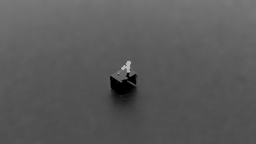

**Round 1 - worker 1 - ep 0** reward=0.759

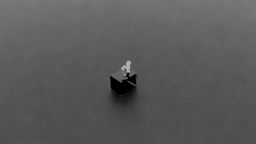

In [7]:
from IPython.display import Image, display, Markdown

for ep in r1_episodes:
    gif = ep.get("gif_path")
    if gif and os.path.exists(gif):
        display(Markdown(f"**Round 1 - worker {ep['worker_id']} - ep {ep['episode']}** "
                         f"reward={ep['total_reward']:.3f}"))
        display(Image(filename=gif))

## Cell 8: The closed loop (`build_mixed_dataset`)

**What you do** — define `build_mixed_dataset`: glob the round-1 trajectory
pickles, parse the reward from each filename, keep episodes with
`reward >= REWARD_THRESHOLD`, turn the kept frames into a Ray Data dataset with
`ray.data.from_items`, and `union()` them with the LIBERO stream.

**What to check** — the one line that closes the loop:
`mixed = libero_ds.union(sim_ds)`. No custom sampler, no DataLoader subclass.

**Why it matters** — data mixing is a one-liner; the training loop is unchanged.

In [8]:
def build_mixed_dataset(libero_ds, round_name):
    """Load sim trajectories from round_name, filter by reward, union with LIBERO.

    Ray Data's union() interleaves both sources during iteration — no custom
    sampler, no DataLoader subclass. The training loop is unchanged.
    """
    traj_dir  = CLUSTER_STORAGE_ROOT / "trajectories" / round_name
    pkl_files = sorted(glob.glob(str(traj_dir / "*.pkl")))

    if not pkl_files:
        print(f"No trajectory files in {traj_dir} — using LIBERO only")
        return libero_ds

    kept_frames = []
    for path in pkl_files:
        try:
            reward = float(Path(path).stem.split("_reward")[-1])
        except (IndexError, ValueError):
            reward = 0.0
        status = "KEEP" if reward >= REWARD_THRESHOLD else "DROP"
        print(f"  {status}  {Path(path).name}  (reward={reward:.3f})")
        if reward >= REWARD_THRESHOLD:
            with open(path, "rb") as f:
                kept_frames.extend(pickle.load(f))

    if not kept_frames:
        print(f"No episodes passed threshold {REWARD_THRESHOLD} — using LIBERO only")
        return libero_ds

    print(f"\nSim frames kept: {len(kept_frames)} "
          f"(from {sum(1 for p in pkl_files if float(Path(p).stem.split('_reward')[-1]) >= REWARD_THRESHOLD)} episodes)")

    sim_ds = (
        ray.data.from_items(kept_frames)
        .map_batches(
            transpose_images, batch_size=32,
            fn_args=(["observation.images.image", "observation.images.image2"],),
        )
    )

    mixed = libero_ds.union(sim_ds)   # <-- THE CLOSED LOOP, one line
    print(f"Mixed dataset: LIBERO ({TOTAL_FRAMES:,} frames) ∪ sim ({len(kept_frames)} frames)")
    return mixed

## Cell 9: Build the mixed dataset

**What you do** — filter round-1 trajectories and union the survivors into LIBERO.

**What to check** — `KEEP`/`DROP` decisions per trajectory and the final mixed
frame counts. At smoke scale with an embodiment mismatch, few or no sim episodes
may clear the threshold — the function falls back to LIBERO-only, which is fine;
the mechanism is the lesson.

**Why it matters** — this is the data artifact the round-2 trainer consumes.

In [9]:
mixed_ds = build_mixed_dataset(build_libero_dataset(), "round1")
print(mixed_ds)

2026-06-08 18:48:40,306  INFO      37 tasks, 273465 total frames, 1 roots, 2 cameras


  KEEP  worker0_ep0_reward0.740.pkl  (reward=0.740)
  KEEP  worker1_ep0_reward0.759.pkl  (reward=0.759)



Sim frames kept: 200 (from 2 episodes)


Mixed dataset: LIBERO (273,465 frames) ∪ sim (200 frames)
Union
+- MapBatches(transpose_images)
   +- Map(rename_columns)
+- MapBatches(transpose_images)
      +- Dataset(num_rows=?, schema=Unknown schema)


## Cell 10: Round-2 retrain on the mixed data

**What you do** — call the **same** `run_training` from Cell 4 on `mixed_ds`.

**What to check** — identical `(RayTrainWorker ...)` `step=`/`loss=` logs as
notebook 02; a `checkpoint_round2/state.pkl` is written.

**Why it matters** — the entire difference between round 1 and round 2 is the
dataset argument. That is the closed loop.

In [10]:
r2_ckpt, r2_metrics = run_training(mixed_ds, "round2")
print("\nRound 2 checkpoint:", r2_ckpt)
print("Round 2 metrics:", r2_metrics)

(TrainController pid=87657) A run snapshot was found in storage folder at: '/mnt/cluster_storage/vla_closed_loop_demo/vla-finetune-round2'
(TrainController pid=87657) This snapshot contains a list of checkpoints reported via `ray.train.report` and will be loaded. This allows the latest checkpoint found in the snapshot to be accessible within your training function via `ray.train.get_checkpoint`.
(TrainController pid=87657) If you meant to start a brand new training job without any information about previous checkpoints found in this directory, please configure a new, unique `RunConfig(name)` or delete the existing folder at '/mnt/cluster_storage/vla_closed_loop_demo/vla-finetune-round2'.
(TrainController pid=87657) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=87657) Attempting to start training worker group of size 4 with the following resources: [{'GPU': 1}] * 4


(RayTrainWorker pid=32721, ip=10.0.65.164) Setting up process group for: env:// [rank=0, world_size=4]


(TrainController pid=87657) Started training worker group of size 4: 
(TrainController pid=87657) - (ip=10.0.65.164, pid=32721) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=87657) - (ip=10.0.71.159, pid=31411) world_rank=1, local_rank=0, node_rank=1
(TrainController pid=87657) - (ip=10.0.93.36, pid=29730) world_rank=2, local_rank=0, node_rank=2
(TrainController pid=87657) - (ip=10.0.86.10, pid=32465) world_rank=3, local_rank=0, node_rank=3
(TrainController pid=87657) [State Transition] SCHEDULING -> RUNNING.


(RayTrainWorker pid=29730, ip=10.0.93.36) The PI05 model is a direct port of the OpenPI implementation. 
(RayTrainWorker pid=29730, ip=10.0.93.36) This implementation follows the original OpenPI structure for compatibility. 
(RayTrainWorker pid=29730, ip=10.0.93.36) Original implementation: https://github.com/Physical-Intelligence/openpi


(RayTrainWorker pid=29730, ip=10.0.93.36) Enabled gradient checkpointing for PI05Pytorch model
(RayTrainWorker pid=32465, ip=10.0.86.10) The PI05 model is a direct port of the OpenPI implementation.  [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(RayTrainWorker pid=32465, ip=10.0.86.10) This implementation follows the original OpenPI structure for compatibility.  [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) Original implementation: https://github.com/Physical-Intelligence/openpi [repeated 3x across cluster]


...

(RayTrainWorker pid=31411, ip=10.0.71.159) Warning: Could not remap state dict keys: Error(s) in loading state_dict for PI05Policy:
(RayTrainWorker pid=31411, ip=10.0.71.159) 	Missing key(s) in state_dict: "model.paligemma_with_expert.paligemma.model.language_model.embed_tokens.weight". 


(RayTrainWorker pid=31411, ip=10.0.71.159) Moving model to device: cuda:0
(RayTrainWorker pid=31411, ip=10.0.71.159) Wrapping provided model in DistributedDataParallel.


(TrainController pid=87657) [State Transition] RUNNING -> SHUTTING_DOWN.
(RayTrainWorker pid=32465, ip=10.0.86.10) Enabled gradient checkpointing for PI05Pytorch model [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) Loading model from: /mnt/local_storage/lerobot/pi05_libero_finetuned [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) ✓ Loaded state dict from model.safetensors [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) Vision embedding key might need handling: model.paligemma_with_expert.paligemma.model.vision_tower.vision_model.embeddings.patch_embedding.bias [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) Vision embedding key might need handling: model.paligemma_with_expert.paligemma.model.vision_tower.vision_model.embeddings.patch_embedding.weight [repeated 3x across cluster]
(RayTrainWorker pid=32465, ip=10.0.86.10) Warning: Could not remap state dict keys: Error(s) in loading state_dict fo

(TrainController pid=87657) [State Transition] SHUTTING_DOWN -> FINISHED.
2026-06-08 18:49:53,415  INFO      [round2] checkpoint -> /mnt/cluster_storage/vla_closed_loop_demo/checkpoint_round2/state.pkl



Round 2 checkpoint: /mnt/cluster_storage/vla_closed_loop_demo/checkpoint_round2/state.pkl
Round 2 metrics: {'epoch': 0, 'steps': 50, 'loss': 1.042230411618948, 'lr': 4.098360655737705e-07}


## Cell 11: Deploy round 2 + sim eval

**What you do** — serve the round-2 checkpoint and run the same sim eval again.

**Why it matters** — head-to-head with round 1 under identical conditions.

In [11]:
r2_episodes = run_sim_eval(r2_ckpt, "round2")
print("\nRound 2 episodes:", len(r2_episodes))

INFO 2026-06-08 18:49:53,433 serve 86435 -- Nothing to shut down. There's no Serve application running on this Ray cluster.


(ProxyActor pid=88772) INFO 2026-06-08 18:49:56,968 proxy 10.0.69.43 -- Proxy starting on node 53f3fb5d6d97c2b52700365428e1bd1692f768affe01f0e1107c3b9c (HTTP port: 8000).
INFO 2026-06-08 18:49:57,040 serve 86435 -- Started Serve in namespace "serve".


INFO 2026-06-08 18:49:57,082 serve 86435 -- Connecting to existing Serve app in namespace "serve". New http options will not be applied.


(ProxyActor pid=88772) INFO 2026-06-08 18:49:57,036 proxy 10.0.69.43 -- Got updated endpoints: {}.


(ServeController pid=88714) INFO 2026-06-08 18:49:57,115 controller 88714 -- Deploying new version of Deployment(name='PI05PolicyServer', app='pi05-policy') (initial target replicas: 1).
(ProxyActor pid=88772) INFO 2026-06-08 18:49:57,118 proxy 10.0.69.43 -- Got updated endpoints: {Deployment(name='PI05PolicyServer', app='pi05-policy'): EndpointInfo(route='/', app_is_cross_language=False, route_patterns=None)}.
(ProxyActor pid=88772) INFO 2026-06-08 18:49:57,127 proxy 10.0.69.43 -- Started <ray.serve._private.router.SharedRouterLongPollClient object at 0x72434011e090>.


...

[round2] Done in 26s


(ServeController pid=88714) INFO 2026-06-08 18:51:24,430 controller 88714 -- Removing 1 replica from Deployment(name='PI05PolicyServer', app='pi05-policy').


(ServeController pid=88714) INFO 2026-06-08 18:51:26,462 controller 88714 -- Replica(id='w3uno55c', deployment='PI05PolicyServer', app='pi05-policy') is stopped.


(raylet) Task ServeController.graceful_shutdown failed. There are infinite retries remaining, so the task will be retried. Error: The actor is dead because it was killed by `ray.kill`.


  host=ip-10-0-86-10 worker=0 exit=0
    ep0: 100 steps, reward=0.741, traj=/mnt/cluster_storage/vla_closed_loop_demo/trajectories/round2/worker0_ep0_reward0.741.pkl
  host=ip-10-0-71-159 worker=1 exit=0
    ep0: 100 steps, reward=0.751, traj=/mnt/cluster_storage/vla_closed_loop_demo/trajectories/round2/worker1_ep0_reward0.751.pkl

Round 2 episodes: 2


## Cell 12: Watch the round-2 rollouts

**Round 2 - worker 0 - ep 0** reward=0.741

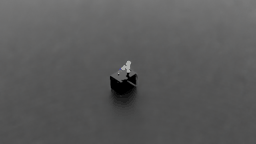

**Round 2 - worker 1 - ep 0** reward=0.751

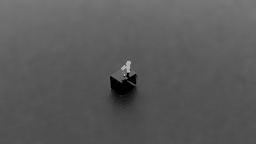

In [12]:
for ep in r2_episodes:
    gif = ep.get("gif_path")
    if gif and os.path.exists(gif):
        display(Markdown(f"**Round 2 - worker {ep['worker_id']} - ep {ep['episode']}** "
                         f"reward={ep['total_reward']:.3f}"))
        display(Image(filename=gif))

## Cell 13: Results — round 1 vs round 2

**What you do** — tabulate sim reward per episode across rounds.

**What to check** — at 50 train steps on a 3.4B model with an embodiment
mismatch, rewards won't move much; the **loop closing** (and the unchanged
trainer) is what this validates. For real movement, set `MAX_TRAIN_STEPS=None`.

**Why it matters** — this is the metric the full-scale flywheel optimizes; here
we prove the plumbing end to end.

In [13]:
print("=" * 56)
print("Sim reward: Round 1 (notebook-02 ckpt) vs Round 2 (mixed)")
print("=" * 56)
print(f"Round 2 training loss: {r2_metrics.get('loss', float('nan')):.4f}")
print()
print(f"{'episode':<12}{'R1 reward':>12}{'R2 reward':>12}{'delta':>10}")
print("-" * 46)

r1_by = {(e['worker_id'], e['episode']): e for e in r1_episodes}
r2_by = {(e['worker_id'], e['episode']): e for e in r2_episodes}
for key in sorted(set(r1_by) | set(r2_by)):
    a = r1_by.get(key, {}).get('total_reward', float('nan'))
    b = r2_by.get(key, {}).get('total_reward', float('nan'))
    print(f"{('w%d ep%d' % key):<12}{a:>12.3f}{b:>12.3f}{(b - a):>+10.3f}")

print("-" * 46)
r1m = np.mean([e['total_reward'] for e in r1_episodes]) if r1_episodes else float('nan')
r2m = np.mean([e['total_reward'] for e in r2_episodes]) if r2_episodes else float('nan')
print(f"{'mean':<12}{r1m:>12.3f}{r2m:>12.3f}{(r2m - r1m):>+10.3f}")
print("=" * 56)

Sim reward: Round 1 (notebook-02 ckpt) vs Round 2 (mixed)
Round 2 training loss: 1.0422

episode        R1 reward   R2 reward     delta
----------------------------------------------
w0 ep0             0.740       0.741    +0.001
w1 ep0             0.759       0.751    -0.008
----------------------------------------------
mean               0.750       0.746    -0.004


## Conclusion

You served a fine-tuned PI0.5 policy with **Ray Serve**, fanned out parallel
**Isaac Lab** rollouts as `@ray.remote(num_gpus=1)` tasks that queried it over
HTTP, then **closed the loop** — filtering sim trajectories by reward and
`union()`-ing them into the LIBERO stream — and retrained with the **unchanged**
trainer from notebook 02.

**Ray primitives used:** `@serve.deployment`, `serve.run`, `@ray.remote(num_gpus=1)`,
`ray.data.from_items`, `ray.data.union`, plus the `TorchTrainer` from 02.

**Scaling levers:** `SIM_WORKERS` (more parallel simulators); Serve replicas /
autoscaling (more inference throughput); `MAX_TRAIN_STEPS=None` (real retrain);
wrap the round in a `for` loop for more flywheel iterations.

Next, **`04_world_model_pretraining.ipynb`** moves from *using* a simulator to
*learning* one: pre-training a V-JEPA world model at scale with the same Ray Data
+ Ray Train stack.